# ERCOT DAM/RTM Nodal Spread Strategy

This notebook reproduces the final analysis for the ERCOT DAM/RTM nodal spread research project. It uses saved results and does not call the ERCOT API.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("..").resolve()
sys.path.append(str(PROJECT_DIR))

from src.config import RESULTS_DIR, FIGURES_DIR
from src.coverage import node_coverage, high_coverage_nodes
from src.research import (
    chronological_train_test_split,
    rank_nodes_on_train,
    evaluate_train_selected_node_baskets,
)
from src.metrics import daily_metrics, clean_metrics_table
from src.backtest import build_lag_strategy_strict

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)


Project directory: /Users/zack/Downloads/TWSQ DataProject/ercot-nodal-spread-research
Results directory: /Users/zack/Downloads/TWSQ DataProject/ercot-nodal-spread-research/results
Figures directory: /Users/zack/Downloads/TWSQ DataProject/ercot-nodal-spread-research/figures


## 2. Load 51-node 90-day backtest data

In [2]:
raw_file = RESULTS_DIR / "ercot_51nodes_90d_raw_backtest.csv"

final_df_51nodes_90d = pd.read_csv(raw_file)

print("Shape:", final_df_51nodes_90d.shape)
print("Unique nodes:", final_df_51nodes_90d["Node"].nunique())
print("Unique dates:", final_df_51nodes_90d["Date"].nunique())
print("Date range:", final_df_51nodes_90d["Date"].min(), "to", final_df_51nodes_90d["Date"].max())

final_df_51nodes_90d.head()


Shape: (89170, 18)
Unique nodes: 51
Unique dates: 90
Date range: 2026-01-25 to 2026-04-24


,RTM_Spread_Avg,HourInt,DeliveryDate,HourEnding_node,BusName_node,LMP_node,DSTFlag_node,HourEnding_hub,BusName_hub,LMP_hub,DSTFlag_hub,DAM_Spread,Alpha_PnL,Net_PnL,Node,DAM_Bus,DAM_Hub,Date
0,20.649167,1,2026-01-25,01:00,AMO_AMOCO_1,287.69,False,01:00,NORTH,475.00,False,187.31,-166.660833,-167.660833,AMO_AMOCO_1,AMO_AMOCO_1,NORTH,2026-01-25
1,14.388333,2,2026-01-25,02:00,AMO_AMOCO_1,260.50,False,02:00,NORTH,483.99,False,223.49,-209.101667,-210.101667,AMO_AMOCO_1,AMO_AMOCO_1,NORTH,2026-01-25
2,21.739167,3,2026-01-25,03:00,AMO_AMOCO_1,252.52,False,03:00,NORTH,470.22,False,217.70,-195.960833,-196.960833,AMO_AMOCO_1,AMO_AMOCO_1,NORTH,2026-01-25
3,29.380833,4,2026-01-25,04:00,AMO_AMOCO_1,332.08,False,04:00,NORTH,517.56,False,185.48,-156.099167,-157.099167,AMO_AMOCO_1,AMO_AMOCO_1,NORTH,2026-01-25
4,15.954615,5,2026-01-25,05:00,AMO_AMOCO_1,288.34,False,05:00,NORTH,512.92,False,224.58,-208.625385,-209.625385,AMO_AMOCO_1,AMO_AMOCO_1,NORTH,2026-01-25


## 3. Build high-coverage node universe

The full matched universe has 51 nodes. We filter to nodes with at least 75% data coverage.

In [3]:
candidate_nodes_51 = sorted(final_df_51nodes_90d["Node"].unique())
dates_to_test_90d = sorted(final_df_51nodes_90d["Date"].unique())

node_cov = node_coverage(final_df_51nodes_90d, dates_to_test_90d)
hc_nodes = high_coverage_nodes(node_cov, min_coverage=0.75)

final_df_hc = final_df_51nodes_90d[
    final_df_51nodes_90d["Node"].isin(hc_nodes)
].copy()

print("Total matched nodes:", len(candidate_nodes_51))
print("High-coverage nodes:", len(hc_nodes))
print("Rows after high-coverage filter:", len(final_df_hc))
print("Unique dates:", final_df_hc["Date"].nunique())

node_cov.sort_values("coverage_ratio").head(15)


Total matched nodes: 51
High-coverage nodes: 40
Rows after high-coverage filter: 73144
Unique dates: 90


,Node,rows,expected_rows,coverage_ratio
8,BIRD_ESR1,695,2160,0.321759
0,AMO_AMOCO_1,1392,2160,0.644444
1,AMO_AMOCO_2,1488,2160,0.688889
23,B_DAVIS_4,1488,2160,0.688889
2,AMO_AMOCO_5,1536,2160,0.711111
3,AMO_AMOCO_G1,1536,2160,0.711111
41,CVC_CVCG1_5,1559,2160,0.721759
28,CALAVER_OWS1,1559,2160,0.721759
42,DDPEC_GT2,1583,2160,0.732870
15,BTE_BTE_G1,1583,2160,0.732870


## 4. Chronological train/test split

In [4]:
train_raw_hc, test_raw_hc, train_dates_hc, test_dates_hc = chronological_train_test_split(
    final_df_hc,
    train_frac=0.5,
)

print("Train:", train_dates_hc[0], "to", train_dates_hc[-1], len(train_dates_hc))
print("Test:", test_dates_hc[0], "to", test_dates_hc[-1], len(test_dates_hc))

print("Train shape:", train_raw_hc.shape)
print("Test shape:", test_raw_hc.shape)
print("Train nodes:", train_raw_hc["Node"].nunique())
print("Test nodes:", test_raw_hc["Node"].nunique())


Train: 2026-01-25 to 2026-03-10 45
Test: 2026-03-11 to 2026-04-24 45
Train shape: (35824, 18)
Test shape: (37320, 18)
Train nodes: 40
Test nodes: 40


## 5. Train-only node ranking

Nodes are ranked using only the training window. The ranking rule uses Hour 10-20 and Lag1_RTM >= 0.

In [5]:
node_rank_train_hc = rank_nodes_on_train(
    train_raw_hc,
    start_hour=10,
    end_hour=20,
    threshold=0,
)

print("Top 20 train-ranked nodes:")
node_rank_train_hc.head(20)


Top 20 train-ranked nodes:


,rows,total_net_pnl,mean_net_pnl,win_rate,std_net_pnl
Node,,,,,
BVE_UNIT3,227,1072.404508,4.724249,0.449339,24.880925
BVE_UNIT2,152,869.164546,5.718188,0.513158,38.239133
B_D_B_DAVIG1,138,715.282058,5.183203,0.557971,23.893855
BVE_UNIT1,176,499.074587,2.835651,0.517045,33.825739
AMO_AMOCO_G2,71,274.933593,3.872304,0.408451,33.754801
CALAVER_OWS2,136,261.523030,1.922963,0.455882,21.854521
CARBN_BSP_1,146,180.006374,1.232920,0.513699,11.440167
BRA_AVR1_CT2,193,118.531717,0.614154,0.430052,19.227754
CPSES_UNIT1,116,107.180587,0.923971,0.396552,9.367918


## 6. Evaluate train-selected node baskets

In [6]:
ranked_nodes = node_rank_train_hc.index.tolist()

basket_comparison_hc = evaluate_train_selected_node_baskets(
    train_raw=train_raw_hc,
    test_raw=test_raw_hc,
    ranked_nodes=ranked_nodes,
    basket_sizes=[3, 5, 10, 15, 20],
    start_hour=10,
    end_hour=20,
    threshold=0,
)

display_cols = [
    "split",
    "basket_size",
    "label",
    "rows",
    "total_net_pnl",
    "mean_trade_pnl",
    "win_rate",
    "annualized_sharpe",
    "max_drawdown",
    "num_days",
    "selected_nodes",
]

basket_comparison_hc[display_cols]


,split,basket_size,label,rows,total_net_pnl,mean_trade_pnl,win_rate,annualized_sharpe,max_drawdown,num_days,selected_nodes
0,train,3,Train top 3 nodes,517,2656.851112,5.138977,0.497099,3.415250,-752.678593,43,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1"
1,test,3,Test top 3 train-selected nodes,362,3770.769789,10.416491,0.682320,6.925565,-187.807104,34,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1"
2,train,5,Train top 5 nodes,764,3430.859293,4.490654,0.493455,3.040995,-938.669326,43,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
3,test,5,Test top 5 train-selected nodes,567,5540.208781,9.771091,0.664903,7.889498,-311.232692,34,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
4,train,10,Train top 10 nodes,1538,4169.476213,2.710973,0.468791,2.446878,-2623.919729,44,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
5,test,10,Test top 10 train-selected nodes,1476,16715.189131,11.324654,0.679539,8.390715,-534.716218,43,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
6,train,15,Train top 15 nodes,2282,4330.267777,1.897576,0.441280,2.255163,-3278.723342,44,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
7,test,15,Test top 15 train-selected nodes,2548,26677.296169,10.469896,0.667582,9.246912,-759.609520,44,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
8,train,20,Train top 20 nodes,2958,3937.806735,1.331240,0.438810,1.706453,-3909.563592,44,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."
9,test,20,Test top 20 train-selected nodes,3082,34403.308706,11.162657,0.664828,8.557088,-989.794846,44,"BVE_UNIT3,BVE_UNIT2,B_D_B_DAVIG1,BVE_UNIT1,AMO..."


## 7. Official Top 15 result

In [7]:
top15_nodes = ranked_nodes[:15]

print("Top 15 train-selected nodes:")
print(top15_nodes)

train_top15_raw = train_raw_hc[
    train_raw_hc["Node"].isin(top15_nodes)
].copy()

test_top15_raw = test_raw_hc[
    test_raw_hc["Node"].isin(top15_nodes)
].copy()

train_top15_strategy = build_lag_strategy_strict(
    train_top15_raw,
    start_hour=10,
    end_hour=20,
    min_lag_rtm=0,
)

test_top15_strategy = build_lag_strategy_strict(
    test_top15_raw,
    start_hour=10,
    end_hour=20,
    min_lag_rtm=0,
)

top15_official_metrics = pd.DataFrame([
    daily_metrics(train_top15_strategy, "Train Top 15 selected strategy"),
    daily_metrics(test_top15_strategy, "Test Top 15 selected strategy"),
])

top15_official_metrics_clean = clean_metrics_table(top15_official_metrics)
top15_official_metrics_clean


Top 15 train-selected nodes:
['BVE_UNIT3', 'BVE_UNIT2', 'B_D_B_DAVIG1', 'BVE_UNIT1', 'AMO_AMOCO_G2', 'CALAVER_OWS2', 'CARBN_BSP_1', 'BRA_AVR1_CT2', 'CPSES_UNIT1', 'BRAUNIG_VHB2', 'CALLAHA_WND1', 'BRTSW_BCW1', 'DSWL_BES1', 'CARRIZO_ESR1', 'BRAZ_WND_ALL']


,label,rows,total_net_pnl,mean_trade_pnl,win_rate,annualized_sharpe,max_drawdown,num_days
0,Train Top 15 selected strategy,2282,4330.27,1.90,44.1,2.26,-3278.72,44
1,Test Top 15 selected strategy,2548,26677.30,10.47,66.8,9.25,-759.61,44


## 8. Save official tables

In [8]:
basket_comparison_hc.to_csv(
    RESULTS_DIR / "official_40hc_train_selected_node_basket_comparison.csv",
    index=False,
)

basket_comparison_hc_clean = basket_comparison_hc[display_cols].copy()
basket_comparison_hc_clean["total_net_pnl"] = basket_comparison_hc_clean["total_net_pnl"].round(2)
basket_comparison_hc_clean["mean_trade_pnl"] = basket_comparison_hc_clean["mean_trade_pnl"].round(2)
basket_comparison_hc_clean["win_rate"] = (basket_comparison_hc_clean["win_rate"] * 100).round(1)
basket_comparison_hc_clean["annualized_sharpe"] = basket_comparison_hc_clean["annualized_sharpe"].round(2)
basket_comparison_hc_clean["max_drawdown"] = basket_comparison_hc_clean["max_drawdown"].round(2)

basket_comparison_hc_clean.to_csv(
    RESULTS_DIR / "official_40hc_train_selected_node_basket_comparison_clean.csv",
    index=False,
)

top15_official_metrics.to_csv(
    RESULTS_DIR / "official_top15_strategy_metrics.csv",
    index=False,
)

top15_official_metrics_clean.to_csv(
    RESULTS_DIR / "official_top15_strategy_metrics_clean.csv",
    index=False,
)

print("Saved official results.")


Saved official results.


## 9. Cumulative PnL chart

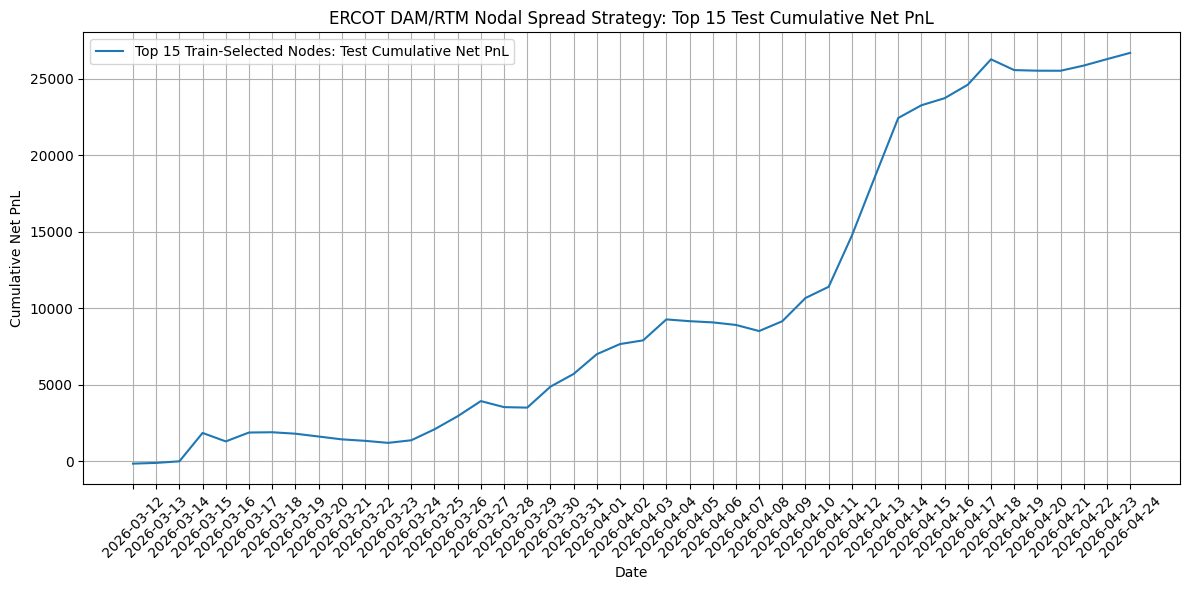

Saved figure to: /Users/zack/Downloads/TWSQ DataProject/ercot-nodal-spread-research/figures/official_top15_test_cumulative_pnl.png


In [9]:
test_top15_daily = (
    test_top15_strategy
    .groupby("Date")["Net_PnL"]
    .sum()
    .sort_index()
)

test_top15_cum = test_top15_daily.cumsum()

plt.figure(figsize=(12, 6))
plt.plot(
    test_top15_cum.index,
    test_top15_cum.values,
    label="Top 15 Train-Selected Nodes: Test Cumulative Net PnL",
)

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Cumulative Net PnL")
plt.title("ERCOT DAM/RTM Nodal Spread Strategy: Top 15 Test Cumulative Net PnL")
plt.legend()
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "official_top15_test_cumulative_pnl.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)


## 10. Drawdown chart

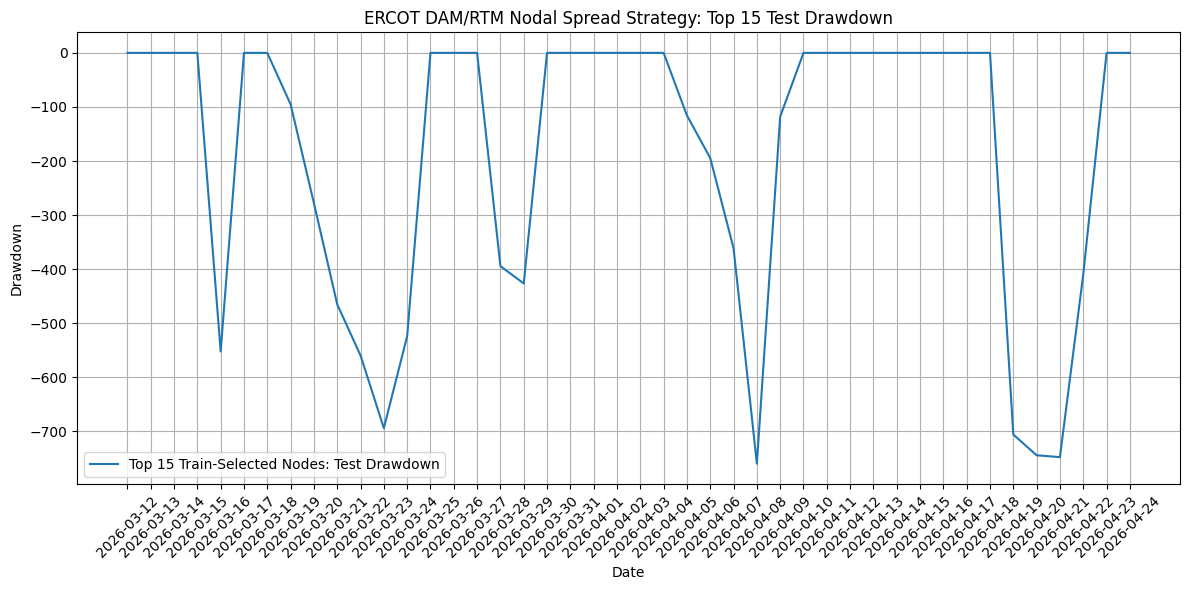

Saved figure to: /Users/zack/Downloads/TWSQ DataProject/ercot-nodal-spread-research/figures/official_top15_test_drawdown.png


In [10]:
test_top15_drawdown = test_top15_cum - test_top15_cum.cummax()

plt.figure(figsize=(12, 6))
plt.plot(
    test_top15_drawdown.index,
    test_top15_drawdown.values,
    label="Top 15 Train-Selected Nodes: Test Drawdown",
)

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("ERCOT DAM/RTM Nodal Spread Strategy: Top 15 Test Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "official_top15_test_drawdown.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)


## 11. Interpretation

The lagged congestion signal is not universally profitable across all ERCOT nodes. A broad all-node basket performed poorly. The main finding is that node selection matters. Using train-only node ranking, the Top 15 selected nodes produced strong out-of-sample performance on the test window.

This project should be interpreted as a research backtest, not a production trading system.